# 3D printer Enclosure Fan For Reduction of Emmisions
The objective of this project is to develop a low cost and printable forced air flow filtration system with the goal to filter out emissions released by the 3d Printer. These emmissions are not safe for humans to breath in over a long period.

An intial study of the emmissions released by 3d printing are as follows.
[Ultrafine particle emissions from desktop 3D printers](https://www.sciencedirect.com/science/article/pii/S1352231013005086)
[Emissions of Ultrafine Particles and Volatile Organic Compounds from Commercially Available Desktop Three-Dimensional Printers with Multiple Filaments](https://pubs.acs.org/doi/abs/10.1021/acs.est.5b04983)

The primary results that we can pull from this are the types, size, and quanitity of emissions.

UFP (Ultra Fine Particles)
Size : <100nm
* Emmission rate(PLA): ~2.0 × 10E10 # min−1
* Emmission Rate(ABS): ∼1.9 × 10E11 # min−1
* Size resolved Range: 11.5nm to 116nm

VOC (Viotolic Organic Compounds)
Primary emissions

* styrene (ABS)(HIPS)  :  ∼10 to ∼110 μg/min
* lactide (PLA)  :  ∼4 to ∼5 μg/min
* caprolactam (nylon-based, imitation wood and brick filaments) :   ∼2 to ∼180 μg/min





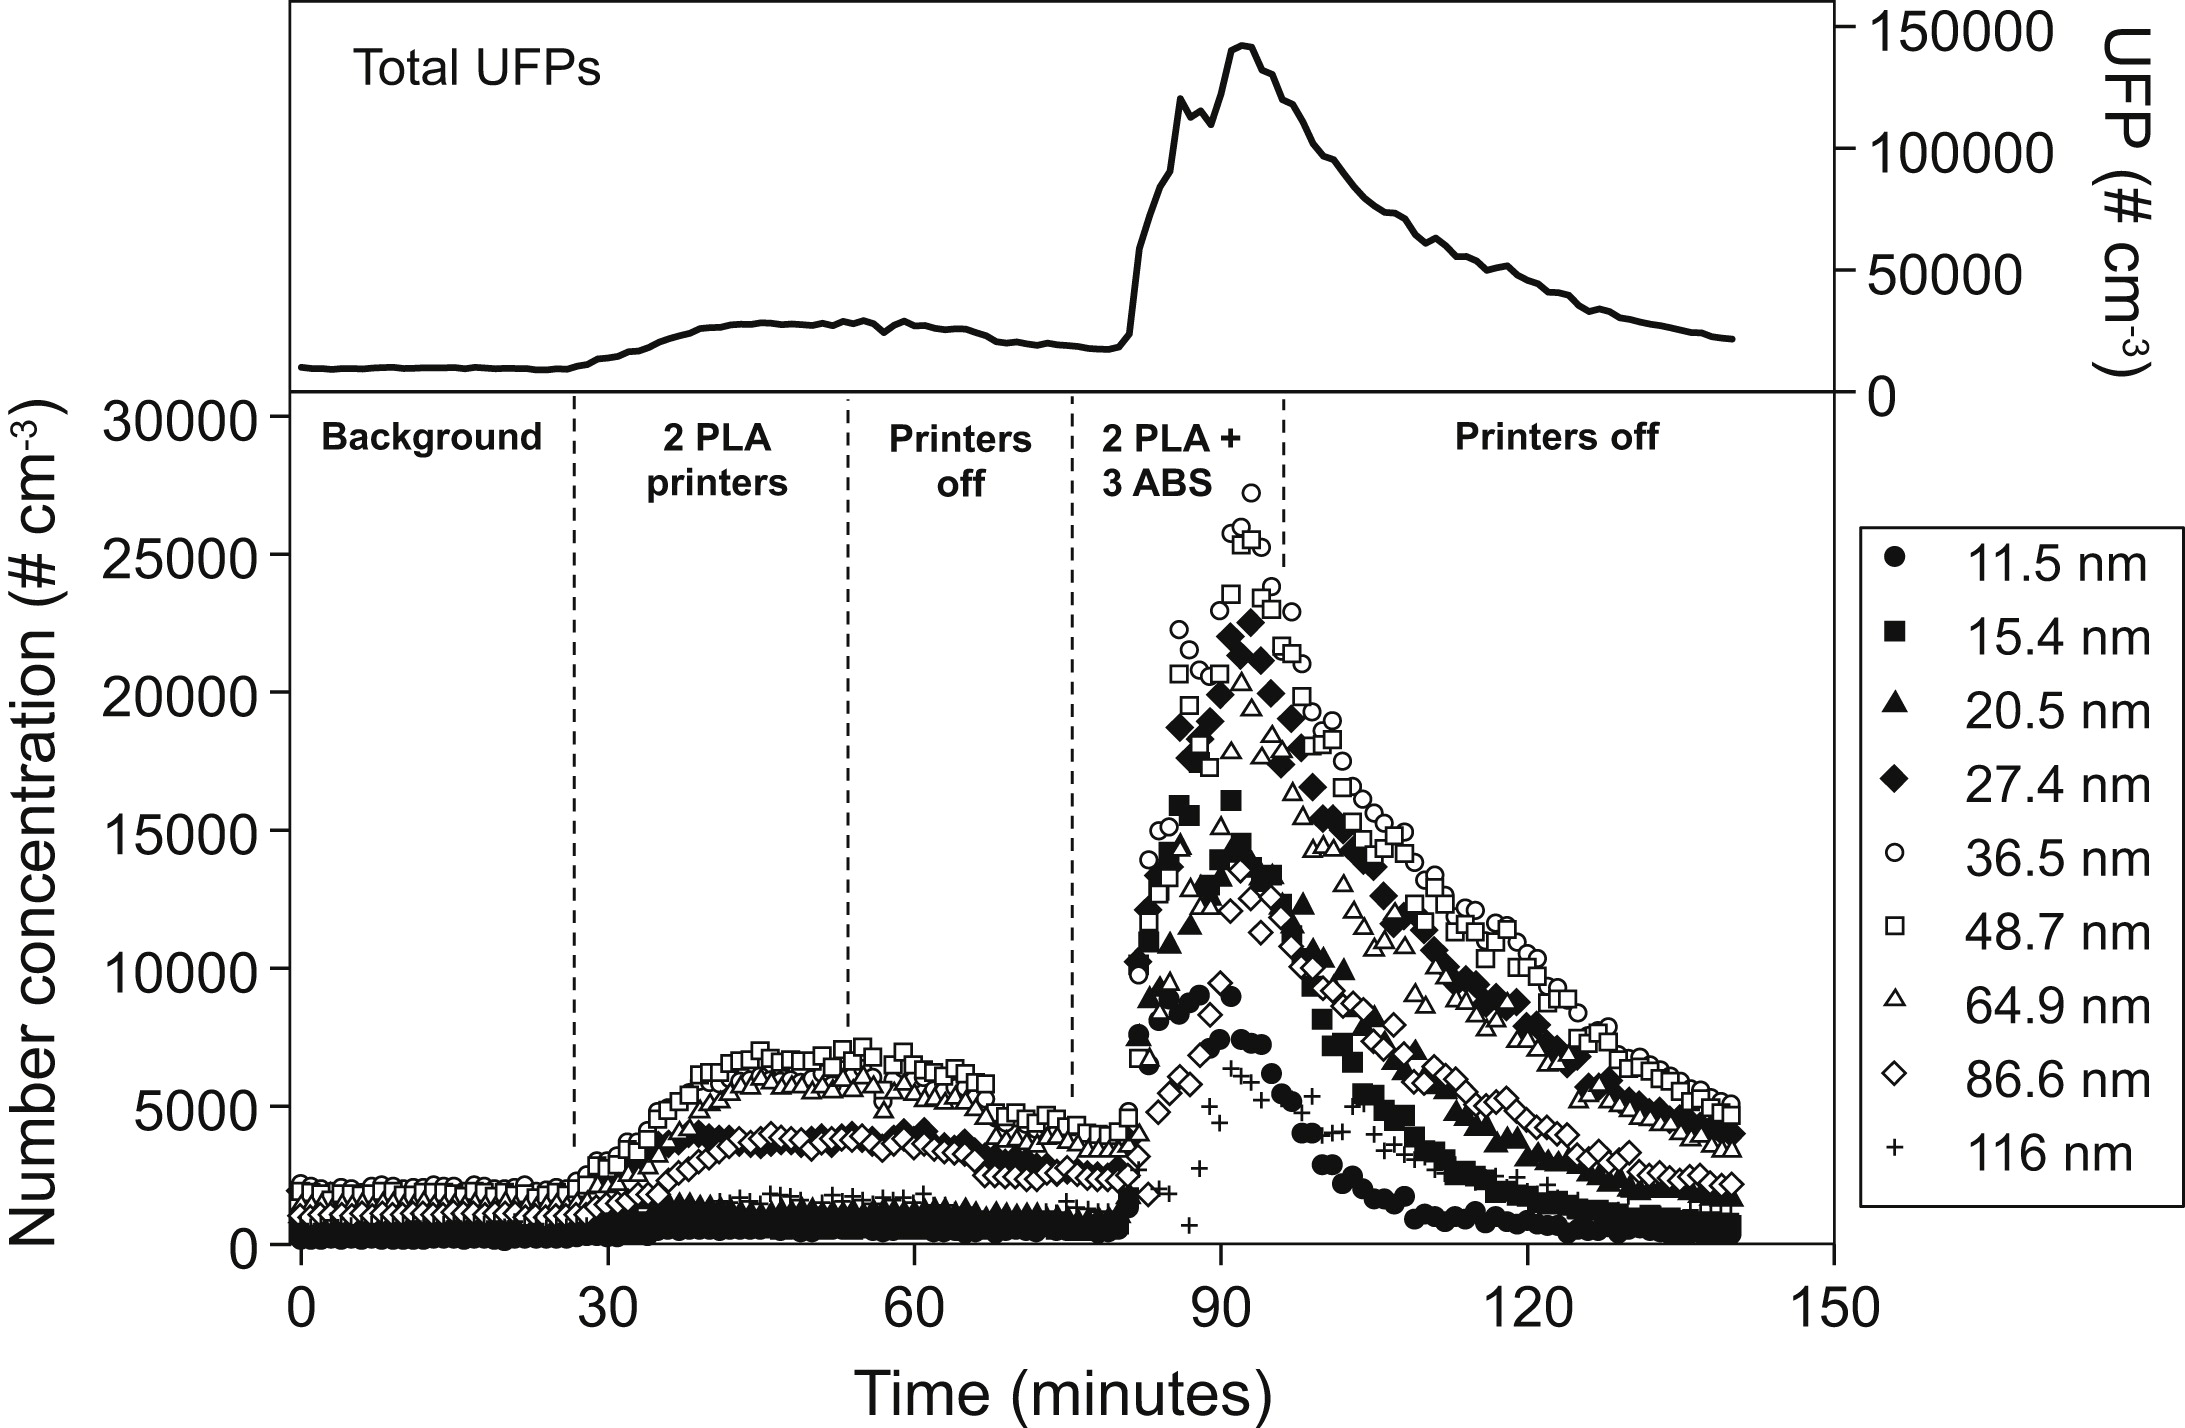

## Previous work
The primary example of previous work from the community can be found here: https://www.prusaprinters.org/prints/16996-airmanagerv2-recirculating-air-filter-for-3d-print
This overall design is the bases for which the following will be utilizing.

# Design

## Filtration Standards


Three types of filters based on my research.
* Activated Carbon
* Merv (Minimum Efficiency Rating Value) Filers
* Hepa filters

We'll start with Merv Filers as I was able to readible find a roll of MERV 16 Filter material (cloth like) on amazon ([MERV 16 Amazon link](https://www.amazon.com/gp/product/B08L3D73VQ/ref=ppx_yo_dt_b_asin_title_o07_s01?ie=UTF8&psc=1)). The following image is useful to see what happens for filteration of paticle sizes.

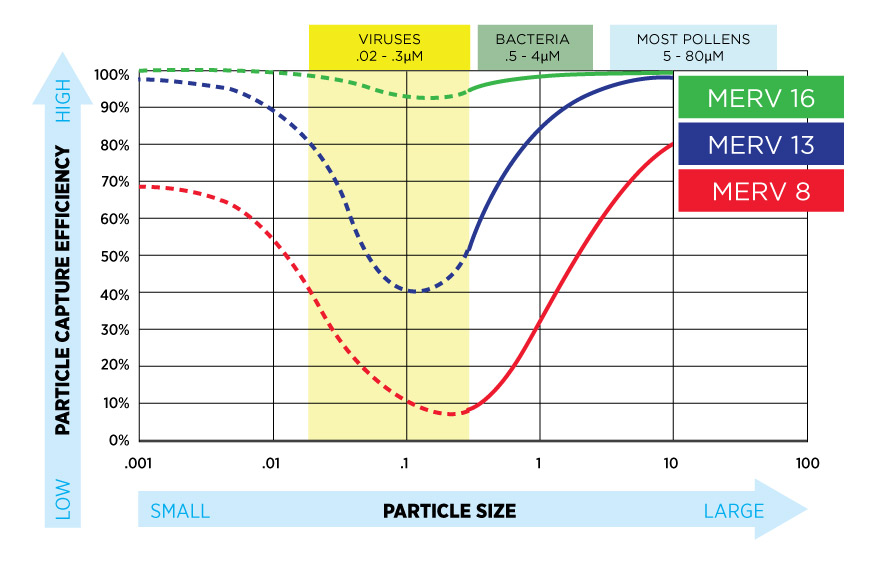

HEPA standard is very similar. There is some very useful information found at [HEPA Wikipedia](https://en.wikipedia.org/wiki/HEPA).
Primarly:
1. It does not filter out gasses / odors. This is were activated carbon.
1. Activated Carbon is typically a pre-filter to most HEPA/MERV filters.

Research Links:
1. [Merv16](https://www.epa.gov/indoor-air-quality-iaq/what-merv-rating-1)







From this, we can conclude activated Carbon then MERV 16 filter system. But will this actually capture our particles? If so, how long will it last?

We have two different contaminents to worry about: VOCs and UFP.

The UFP range from 11.5nm to 116nm. Converting to $\mu m$

In [5]:
11.5e-9/1e-6

0.011500000000000002

In [7]:
116e-9/1e-6

0.116

So that is a range for 0.01 to 0.12 $\mu m$ which is nearly 100% coverage range for a MERV 16 filter. UFP filtered: **check**

Life span of MERV 16 filter?

## Activated Carbon

First, there does not appear to be any standards for Activated carbon so everything will have to be by the manufactures specifications. 
[The best overview so far of Activated Carbon](https://en.wikipedia.org/wiki/Activated_carbon#Environmental)
[Basic Info on Activated Carbon](https://molekule.science/activated-carbon-air-filter/)  
[Basic Info part 2](https://enviroklenzairpurifiers.com/how-long-does-activated-carbon-last-in-air-filter/)  
* Activation part is taking carbon or charcoal and putting steam or hot gas or certain chemicals through it to drastically increase its surface area 

[List of VOCs known to be absorbed by Activated Carbon](https://cuzn.com/home/water-filter-replacement-cartridges/what-does-activated-carbon-filter/)  
* Note that Styrene is listed but the other two primary VOCs for 3d Printing are not. However, this website specifically only lists VOCs for water and indicates that it is not a complete list.

[A more complete list of filtered compounds](https://www.sentryair.com/activated-carbon-adsorption.htm)  
* Note: Styrene and Lactide are both adsorbed by AC. However, caprolactam is not listed. Though given it is nylon only by-product we may ignore this for now.

It does eventually become saturated and need replacing but there are too many variables to tell when. Primarily, variations and lack of testing on the manufacturing end as well as size and quantity of each different trapped gas molecule.

Other factors that dictate effectiveness of filters:

* Dwell Time
    * amount of time that the air resides inside of the filter. More time inside the filter means higher likelyhood that contaminents will be filtered out.
    
* Surface area
* Micropore size

    
    

Probably want Granulated Activated Carbon (GAC) for its greater surface area and small micropore size. The cloth or woven carbon filter have so little mass that they will most likely A) not last long B) be ineffective due to very small dwell times.


### In conclusion:
activated carbon will filter out most of the VOCs that we will encounter during 3d Printing. While, MERV / HEPA filter will remove larger particles as compared to the 1E-10m size molecules vs 10e-9m particles. Therefore, pre-filter with MERV filter then have the air pass through a large layer of Granulated Activated Carbon (GAC).

To calculate adsorption rate of Activated Carbon see:  
[paper 1](https://journals.sagepub.com/doi/pdf/10.1260/0263-6174.29.1.71)  
[paper 2](https://www.diva-portal.org/smash/get/diva2:142987/FULLTEXT01.pdf)



Other considerations:
- Air re-ciruclation (requires a sealed or nearly sealed enclosure) to prevent cold drafts for better printing of ABS and Nylon
- amount of air to filter (CFM fan rating)
- Pressure head to move air through filter membrane
- If not re-cirulating air and have an un-sealed enclosure, how to ensure negative pressure inside enclosure to ensure contaminents won't escape
    

After semi-reading paper 1 and 2 above, it turns out there are so many variables on the performance of Activated Carbon GAC that there is no practical way to calculate this. Additionally, all calculation we could do will be regression based off of experimental data.

Therefore, changing directive, we are going to have to make our own experiment and to do that we will need to measure VOCs. 


## Measuring VOCs

Originally (before I began this document), my research showed that measuring VOCs would be very very expensive (>$3000) per device. But on second pass, I found sensors called Hotplate-Metal-oxide or hot-plate MOx. These are able to sense VOCs because chemistry and adsorption (fill this out with specifics, maybe a different section). These are cheap Arduino breakout boards that can be used to at minimum detect the concentration of total VOCs. Possibly detect individuals by using regression data but that more than we need.

sources:
- [MOx Sensor SPG30](https://learn.adafruit.com/adafruit-sgp30-gas-tvoc-eco2-mox-sensor)
- [MOx Sensor SPG40 - next gen](https://learn.adafruit.com/adafruit-sgp40/overview)
- [Paper on correlating MOx sensor data to identify compounds using co-located expensive sensors](https://amt.copernicus.org/articles/12/1441/2019/amt-12-1441-2019.pdf)

- [SPG40 + SHT31 Library Code and Examples](https://github.com/adafruit/Adafruit_SGP40)



side note: temp and humidity sensors need to be with it as well.
- [Temp and Humidity Sensor SHT31](https://www.adafruit.com/product/2857)

Okay, the idea / experiment:
- one sensor in room away from printer - provides baseline values
- one sensor inside of enclosure - for experimental proof, detect rise of VOCs
- one sensor at outlet of filter - detect "cleanliness" of outlet air (ideally, should be within a few % of baseline) (additionally, allows for detection of filter breakthrough and efficiency)

Total 3 sensor suits comprised of MOx, humidity, Temperature, Arduino, inter-arduino/ PI communication.


Plus side: this could be first step into developing DIY smart home stuff